<a href="https://colab.research.google.com/github/cristinasarakefi-art/TugasAkhirS1/blob/main/Penelitian%2015%20ini%20FIXXX%20Untitled40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from google.colab import files

# 1. Upload File CSV
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 2. Baca Dataset
df = pd.read_csv(file_name, sep=None, engine='python')

# Membersihkan spasi pada nama header kolom
df.columns = df.columns.str.strip()

# Membersihkan spasi pada nilai teks (Nama & Bidang Minat)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Konversi IPK Semester 3 dari format koma (2,79) ke float (2.79)
df['IPK Semester 3'] = df['IPK Semester 3'].str.replace(',', '.').astype(float)

display(HTML("<b>=== BAGIAN 1: DATASET BERHASIL DI-LOAD ===</b>"))
display(HTML(f"Total Jumlah Data: <b>{len(df)} baris</b>"))
display(df.head())

Saving Data Mentah Penelitian Skripsi 5.csv to Data Mentah Penelitian Skripsi 5.csv


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,A,C,C,15,15,29
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,A-,B-,C+,17,27,25
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,A,B+,AB,30,35,32
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,AB,B-,C,20,7,33
4,Epin Modjo,Teknik Komputer & Kendali,2.91,B+,B-,AB,29,21,35


In [5]:
kolom_nama = 'Nama Lengkap'
kolom_target = 'Bidang Minat'
kolom_fitur = [c for c in df.columns if c not in [kolom_nama, kolom_target]]

# Bersihkan spasi pada target
df[kolom_target] = df[kolom_target].astype(str).str.strip()

# Pembagian data 80:20 secara berurutan (Sequential Split)
# 80 Data Latih Pertama (Indeks 0 s.d. 79)
train_idx = df.index[:80]

# 20 Data Uji Terakhir (Indeks 80 s.d. 99, dimulai dari Victoria christin Tokan)
test_idx = df.index[80:]

# Ambil Subset Data Latih & Data Uji
df_train = df.loc[train_idx].copy()
df_test = df.loc[test_idx].copy()

df_summary = pd.DataFrame({
    'Jenis Data': ['Data Latih (80%)', 'Data Uji (20%)', 'Total Dataset'],
    'Rentang Baris': ['Baris 1 - 80 (Kristina s.d. Yuvensia)', 'Baris 81 - 100 (Victoria s.d. Lorensius)', '1 - 100'],
    'Jumlah Baris': [len(df_train), len(df_test), len(df)]
})

display(HTML("<b>=== BAGIAN 2: HASIL PEMISAHAN DATASET (80:20 BERURUTAN) ===</b>"))
display(df_summary.style.hide(axis='index'))

# Menampilkan 5 Data Pertama Data Latih (Dimulai dari Kristina Sara Sunia Kefi)
display(HTML("<br><b>Tabel 4.1: 5 Data Pertama Data Latih (Dimulai dari Kristina):</b>"))
display(df_train.head(5))

# Menampilkan 5 Data Pertama Data Uji (Dimulai dari Victoria christin Tokan)
display(HTML("<br><b>Tabel 4.2: 5 Data Pertama Data Uji (Dimulai dari Victoria):</b>"))
display(df_test.head(5))

Jenis Data,Rentang Baris,Jumlah Baris
Data Latih (80%),Baris 1 - 80 (Kristina s.d. Yuvensia),80
Data Uji (20%),Baris 81 - 100 (Victoria s.d. Lorensius),20
Total Dataset,1 - 100,100


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,A,C,C,15,15,29
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,A-,B-,C+,17,27,25
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,A,B+,AB,30,35,32
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,AB,B-,C,20,7,33
4,Epin Modjo,Teknik Komputer & Kendali,2.91,B+,B-,AB,29,21,35


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
80,Victoria christin Tokan,Teknik Komputer & Kendali,3.16,B,C+,B,20,17,35
81,RUTH SALOMI TANGLAWA,Teknik Tenaga Listrik,3.06,B-,BC,B-,31,18,21
82,Alexandro Anggi Nino,Teknik Komputer & Kendali,3.01,C,C,A,28,26,33
83,OVI HALENA TALAEN,Teknik Komputer & Kendali,3.20,B-,BC,B,21,21,27
84,Yanto Mercurius Oematan,Teknik Telekomunikasi,2.99,B,A-,AB,18,24,16


In [28]:
import pandas as pd
from IPython.display import display, HTML

# 1. Map Bobot Nilai Huruf Mata Kuliah ke Angka (0 - 4)
map_nilai = {
    'A': 4.00, 'A-': 3.75, 'AB': 3.50, 'B+': 3.25, 'B': 3.00,
    'B-': 2.75, 'BC': 2.50, 'C+': 2.25, 'C': 2.00, 'C-': 1.75,'CD':1.50,
    'D+': 1.25, 'D': 1.00, 'E': 0.00
}

kolom_matkul = [c for c in df.columns if c.startswith('Nilai mata kuliah')]

# 2. Fungsi Encoding Terpisah untuk Mencegah Kebocoran Data
def encode_nilai_matkul(data_df):
    df_out = data_df.copy()
    for col in kolom_matkul:
        df_out[col] = df_out[col].astype(str).str.strip().map(map_nilai)
    return df_out

# 3. Penerapan Encoding pada Data Latih (80 Data) & Data Uji (20 Data)
df_train_encoded = encode_nilai_matkul(df_train)
df_test_encoded = encode_nilai_matkul(df_test)

# Tambahkan Kolom Keterangan Status Data untuk Dokumentasi Laporan Skripsi
df_train_encoded['Status Data'] = 'Data Latih (80%)'
df_test_encoded['Status Data'] = 'Data Uji (20%)'

# 4. Penggabungan Kembali Menjadi 100 Data Hasil Encoding (Sebelum Normalisasi)
df_100_encoded = pd.concat([df_train_encoded, df_test_encoded], axis=0).reset_index(drop=True)
df_100_encoded.index = df_100_encoded.index + 1  # Mengubah nomor indeks dimulai dari 1 s.d. 100

# Susun ulang posisi kolom agar rapi saat ditampilkan
kolom_tampil = ['Status Data', 'Nama Lengkap', 'Bidang Minat', 'IPK Semester 3'] + kolom_matkul + ['Nilai Skor Minat TTL', 'Nilai Skor Minat TTT', 'Nilai Skor Minat TKK']
df_100_encoded_tabel = df_100_encoded[kolom_tampil]

# 5. Tampilkan Hasil
display(HTML("<b>=== RESULT: 100 DATA HASIL LABEL ENCODING (SEBELUM NORMALISASI) ===</b>"))
display(HTML("<b>Tabel Sampel 5 Data Latih Pertama Setelah Label Encoding:</b>"))
display(df_train_encoded[kolom_tampil].head(5).style.hide(axis='index'))

display(HTML("<br><b>Tabel Sampel 5 Data Uji Pertama Setelah Label Encoding (Dimulai dari Victoria):</b>"))
display(df_test_encoded[kolom_tampil].head(5).style.hide(axis='index'))

display(HTML("<br><b>Tabel 100 Data Keseluruhan Hasil Encoding (Tampilan 10 Data Pertama):</b>"))
display(df_100_encoded_tabel.head(10))

# Menampilkan 10 Data Terakhir (Baris 91 - 100)
display(HTML("<br><b>Tampilan 10 Data Terakhir (Baris 91 - 100):</b>"))
display(df_100_encoded_tabel.tail(10))

Status Data,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
Data Latih (80%),Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.790000,4.000000,2.000000,2.000000,15,15,29
Data Latih (80%),Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.790000,3.750000,2.750000,2.250000,17,27,25
Data Latih (80%),Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.730000,4.000000,3.250000,3.500000,30,35,32
Data Latih (80%),JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.480000,3.500000,2.750000,2.000000,20,7,33
Data Latih (80%),Epin Modjo,Teknik Komputer & Kendali,2.910000,3.250000,2.750000,3.500000,29,21,35


Status Data,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
Data Uji (20%),Victoria christin Tokan,Teknik Komputer & Kendali,3.160000,3.000000,2.250000,3.000000,20,17,35
Data Uji (20%),RUTH SALOMI TANGLAWA,Teknik Tenaga Listrik,3.060000,2.750000,2.500000,2.750000,31,18,21
Data Uji (20%),Alexandro Anggi Nino,Teknik Komputer & Kendali,3.010000,2.000000,2.000000,4.000000,28,26,33
Data Uji (20%),OVI HALENA TALAEN,Teknik Komputer & Kendali,3.200000,2.750000,2.500000,3.000000,21,21,27
Data Uji (20%),Yanto Mercurius Oematan,Teknik Telekomunikasi,2.990000,3.000000,3.750000,3.500000,18,24,16


,Status Data,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
1,Data Latih (80%),Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,4.00,2.00,2.00,15,15,29
2,Data Latih (80%),Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,3.75,2.75,2.25,17,27,25
3,Data Latih (80%),Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,4.00,3.25,3.50,30,35,32
4,Data Latih (80%),JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,3.50,2.75,2.00,20,7,33
5,Data Latih (80%),Epin Modjo,Teknik Komputer & Kendali,2.91,3.25,2.75,3.50,29,21,35
6,Data Latih (80%),Diorrani Simma' Katemba,Teknik Komputer & Kendali,3.55,3.25,4.00,4.00,10,10,30
7,Data Latih (80%),Jachobus Matheus Haekase,Teknik Komputer & Kendali,2.48,3.50,3.75,2.00,27,25,31
8,Data Latih (80%),Maria Kristania Virginia fahik,Teknik Komputer & Kendali,2.79,3.75,3.75,4.00,21,23,29
9,Data Latih (80%),Goysiota Jehanat,Teknik Komputer & Kendali,3.06,4.00,3.50,2.75,11,8,30
10,Data Latih (80%),GERSON YULIUS MARIA NAHAK,Teknik Komputer & Kendali,3.03,3.25,2.75,3.00,23,18,35


,Status Data,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
91,Data Uji (20%),Phylia Chisty Boimau,Teknik Komputer & Kendali,2.61,3.00,3.00,2.50,22,16,25
92,Data Uji (20%),Rafles Riwu Djeta,Teknik Telekomunikasi,3.32,3.00,4.00,2.75,22,30,26
93,Data Uji (20%),Deni Umbu Ndilu Hamba Banju,Teknik Tenaga Listrik,3.45,4.00,4.00,3.00,28,27,21
94,Data Uji (20%),Vickry Adinarto Fuah,Teknik Komputer & Kendali,3.03,3.00,3.25,3.25,25,21,30
95,Data Uji (20%),claudio alves talalab,Teknik Tenaga Listrik,3.06,3.25,3.75,4.00,35,29,29
96,Data Uji (20%),Tesalonika Messakh,Teknik Komputer & Kendali,3.57,3.50,3.75,4.00,26,23,30
97,Data Uji (20%),Reynaldi Hadi Djo,Teknik Komputer & Kendali,2.92,3.00,2.50,3.50,22,14,28
98,Data Uji (20%),Nafian Agazhi,Teknik Tenaga Listrik,3.81,3.50,3.75,4.00,35,17,21
99,Data Uji (20%),Nover Morestu Ndun,Teknik Tenaga Listrik,3.23,4.00,4.00,4.00,29,21,21
100,Data Uji (20%),Lorensius Vikundo Saku,Teknik Telekomunikasi,3.03,3.00,3.25,3.00,22,27,19


In [29]:
map_nilai = {
    'A': 4.00, 'A-': 3.75, 'AB': 3.50, 'B+': 3.25, 'B': 3.00,
    'B-': 2.75, 'BC': 2.50, 'C+': 2.25, 'C': 2.00, 'C-': 1.75,'CD':1.50,
    'D+': 1.25, 'D': 1.00, 'E': 0.00
}

kolom_matkul = [c for c in df.columns if c.startswith('Nilai mata kuliah')]
kolom_skor = ['Nilai Skor Minat TTL', 'Nilai Skor Minat TTT', 'Nilai Skor Minat TKK']

def preprocess_and_scale(data_df):
    df_out = data_df.copy()
    for col in kolom_matkul:
        df_out[col] = df_out[col].astype(str).str.strip().map(map_nilai)
    for col in ['IPK Semester 3'] + kolom_matkul:
        df_out[col] = (df_out[col] - 0) / (4 - 0)
    for col in kolom_skor:
        df_out[col] = (df_out[col] - 7) / (35 - 7)
    return df_out

# Scaling Terpisah
df_train_scaled = preprocess_and_scale(df_train)
df_test_scaled = preprocess_and_scale(df_test)

X_train = df_train_scaled[kolom_fitur].values
y_train = df_train_scaled[kolom_target].values
X_test = df_test_scaled[kolom_fitur].values
y_test = df_test_scaled[kolom_target].values

display(HTML("<b>=== SEL 3: HASIL NORMALISASI MIN-MAX SCALING ===</b>"))
display(HTML("<b>Tabel 3.1: Sampel Data Latih Ter-normalisasi (5 Data Pertama):</b>"))
display(df_train_scaled[[kolom_nama] + kolom_fitur].head(5).style.hide(axis='index'))

display(HTML("<br><b>Tabel 3.2: Sampel Data Uji Ter-normalisasi (5 Data Pertama):</b>"))
display(df_test_scaled[[kolom_nama] + kolom_fitur].head(5).style.hide(axis='index'))

Nama Lengkap,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
Kristina Sara Sunia Kefi,0.697500,1.000000,0.500000,0.500000,0.285714,0.285714,0.785714
Kartini Riyani Boni Geti,0.697500,0.937500,0.687500,0.562500,0.357143,0.714286,0.642857
Fransiska Romana Dua Yustin Nellu,0.682500,1.000000,0.812500,0.875000,0.821429,1.000000,0.892857
JUFRIDSON LAY WOHE,0.620000,0.875000,0.687500,0.500000,0.464286,0.000000,0.928571
Epin Modjo,0.727500,0.812500,0.687500,0.875000,0.785714,0.500000,1.000000


Nama Lengkap,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
Victoria christin Tokan,0.790000,0.750000,0.562500,0.750000,0.464286,0.357143,1.000000
RUTH SALOMI TANGLAWA,0.765000,0.687500,0.625000,0.687500,0.857143,0.392857,0.500000
Alexandro Anggi Nino,0.752500,0.500000,0.500000,1.000000,0.750000,0.678571,0.928571
OVI HALENA TALAEN,0.800000,0.687500,0.625000,0.750000,0.500000,0.500000,0.714286
Yanto Mercurius Oematan,0.747500,0.750000,0.937500,0.875000,0.392857,0.607143,0.321429


In [30]:
def hitung_euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

idx_uji = 0
sampel_uji = X_test[idx_uji]
nama_uji = df_test.iloc[idx_uji][kolom_nama]

daftar_jarak = []
for i in range(len(X_train)):
    jarak = hitung_euclidean_distance(sampel_uji, X_train[i])
    daftar_jarak.append({
        'No Data Latih': i + 1,
        'Nama Mahasiswa Latih': df_train.iloc[i][kolom_nama],
        'Bidang Minat (Kelas)': y_train[i],
        'Euclidean Distance': round(jarak, 6)
    })

df_jarak_sorted = pd.DataFrame(daftar_jarak).sort_values(by='Euclidean Distance', ascending=True).reset_index(drop=True)
df_jarak_sorted['Peringkat Tetangga'] = df_jarak_sorted.index + 1

tabel_top11 = df_jarak_sorted[['Peringkat Tetangga', 'No Data Latih', 'Nama Mahasiswa Latih', 'Bidang Minat (Kelas)', 'Euclidean Distance']].head(11)

display(HTML(f"<b>=== SEL 4: PENGURUTAN JARAK ASCENDING ({nama_uji}) ===</b>"))
display(HTML("<b>Tabel 4.1: Top 11 Tetangga Terdekat (Ascending):</b>"))
display(tabel_top11.style.hide(axis='index'))

Peringkat Tetangga,No Data Latih,Nama Mahasiswa Latih,Bidang Minat (Kelas),Euclidean Distance
1,10,GERSON YULIUS MARIA NAHAK,Teknik Komputer & Kendali,0.182600
2,55,Yohana Palestrina Kobesi,Teknik Komputer & Kendali,0.229837
3,26,Yedija Wiliems Mooy,Teknik Komputer & Kendali,0.247167
4,5,Epin Modjo,Teknik Komputer & Kendali,0.403469
5,79,Regina Ilon Fernandes,Teknik Komputer & Kendali,0.460178
6,1,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,0.469437
7,4,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,0.505275
8,11,Andre Namah,Teknik Komputer & Kendali,0.514204
9,16,cristo sutiray,Teknik Komputer & Kendali,0.538646
10,15,Diana Banunaek,Teknik Komputer & Kendali,0.540882


In [31]:
from collections import Counter

def prediksi_knn_tunggal(X_tr, y_tr, x_te, k):
    distances = [hitung_euclidean_distance(x_te, x_sampel) for x_sampel in X_tr]
    idx_k_terdekat = np.argsort(distances)[:k]
    label_k_terdekat = [y_tr[i] for i in idx_k_terdekat]
    voting = Counter(label_k_terdekat)
    hasil_prediksi = voting.most_common(1)[0][0]
    return hasil_prediksi, voting, label_k_terdekat

k_pilihan = 11
prediksi, hasil_voting, _ = prediksi_knn_tunggal(X_train, y_train, sampel_uji, k=k_pilihan)

df_voting = pd.DataFrame({
    'Bidang Minat': list(hasil_voting.keys()),
    'Jumlah Suara (Tetangga)': list(hasil_voting.values()),
    'Persentase Suara': [f"{(v/k_pilihan)*100:.2f}%" for v in hasil_voting.values()]
}).sort_values(by='Jumlah Suara (Tetangga)', ascending=False)

df_hasil_klasifikasi = pd.DataFrame({
    'Nama Mahasiswa Uji': [nama_uji],
    'Bidang Minat Asli': [y_test[idx_uji]],
    'Hasil Prediksi K-NN': [prediksi],
    'Status Kesesuaian': ['Sesuai (Cocok)' if y_test[idx_uji] == prediksi else 'Tidak Sesuai']
})

display(HTML(f"<b>=== SEL 5: HASIL KLASIFIKASI VOTING (K = {k_pilihan}) ===</b>"))
display(HTML("<b>Tabel 5.1: Rincian Perolehan Suara Voting 11 Tetangga Terdekat:</b>"))
display(df_voting.style.hide(axis='index'))

display(HTML("<br><b>Tabel 5.2: Kesimpulan Klasifikasi Data Uji 1:</b>"))
display(df_hasil_klasifikasi.style.hide(axis='index'))

Bidang Minat,Jumlah Suara (Tetangga),Persentase Suara
Teknik Komputer & Kendali,10,90.91%
Teknik Tenaga Listrik,1,9.09%


Nama Mahasiswa Uji,Bidang Minat Asli,Hasil Prediksi K-NN,Status Kesesuaian
Victoria christin Tokan,Teknik Komputer & Kendali,Teknik Komputer & Kendali,Sesuai (Cocok)


=== SEL 6: EVALUASI PERFORMA MODEL K-NN DENGAN CLASSIFICATION REPORT & CONFUSION MATRIX ===

               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 3
----------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.86      0.92         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.86      0.86      0.86         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



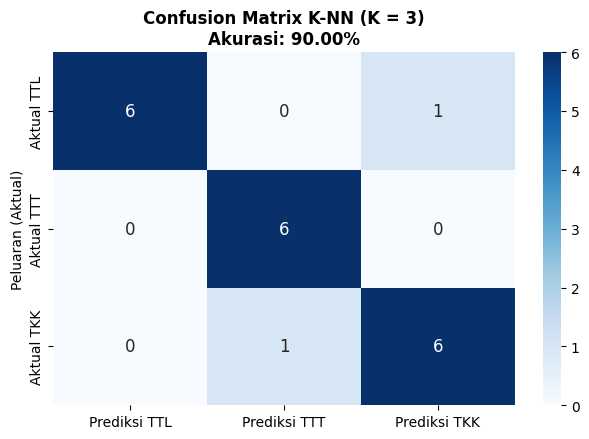


               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 5
----------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.86      0.92         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.86      0.86      0.86         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



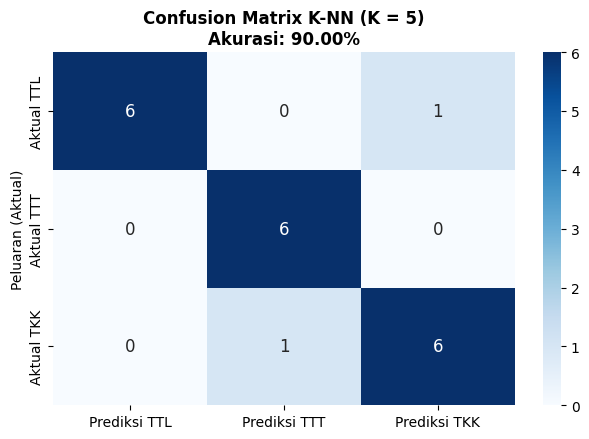


               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 7
----------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.86      0.92         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.86      0.86      0.86         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



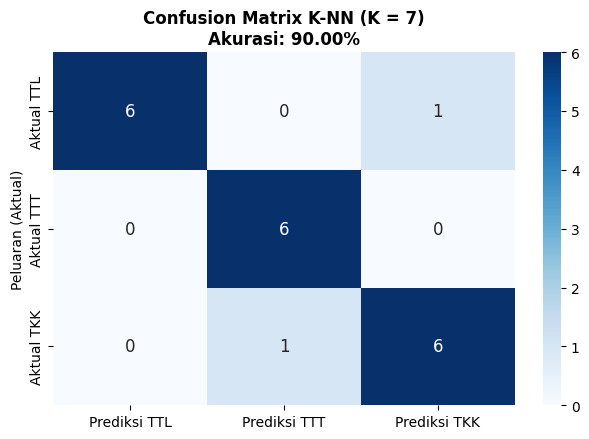


               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 9
----------------------------------------------------------------------
Akurasi Sistem : 85.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.71      0.83         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.75      0.86      0.80         7

                 accuracy                           0.85        20
                macro avg       0.87      0.86      0.85        20
             weighted avg       0.87      0.85      0.85        20



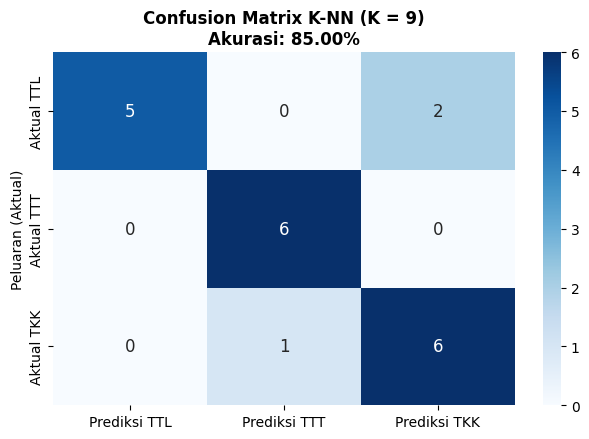


               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 11
----------------------------------------------------------------------
Akurasi Sistem : 85.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.71      0.83         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.75      0.86      0.80         7

                 accuracy                           0.85        20
                macro avg       0.87      0.86      0.85        20
             weighted avg       0.87      0.85      0.85        20



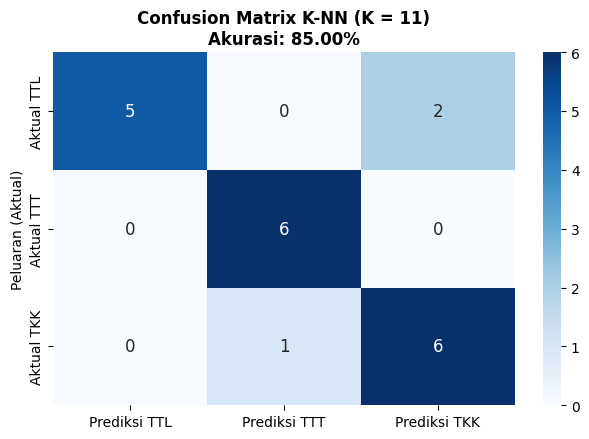

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

list_k = [3, 5, 7, 9, 11]
labels_unik = sorted(list(set(y_train)))

# Singkatan label agar tampilan sumbu grafik rapi seperti di gambar
labels_singkat_y = ['Aktual TTL', 'Aktual TTT', 'Aktual TKK']
labels_singkat_x = ['Prediksi TTL', 'Prediksi TTT', 'Prediksi TKK']

print("=== SEL 6: EVALUASI PERFORMA MODEL K-NN DENGAN CLASSIFICATION REPORT & CONFUSION MATRIX ===")

for k in list_k:
    # 1. Prediksi Data Uji untuk Nilai K Terkait
    y_pred_k = [prediksi_knn_tunggal(X_train, y_train, x_te, k=k)[0] for x_te in X_test]

    # 2. Hitung Akurasi & Cetak Classification Report persis format gambar
    acc = accuracy_score(y_test, y_pred_k)
    report = classification_report(y_test, y_pred_k, target_names=labels_unik, digits=2)

    print("\n" + "="*70)
    print(f"               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = {k}")
    print("-" * 70)
    print(f"Akurasi Sistem : {acc*100:.2f}%\n")
    print("Classification Report:")
    print(report)

    # 3. Visualisasi Heatmap Confusion Matrix persis format gambar
    cm = confusion_matrix(y_test, y_pred_k, labels=labels_unik)

    plt.figure(figsize=(6.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_singkat_x,
                yticklabels=labels_singkat_y,
                cbar=True, annot_kws={"size": 12})

    plt.title(f'Confusion Matrix K-NN (K = {k})\nAkurasi: {acc*100:.2f}%', fontsize=12, fontweight='bold')
    plt.ylabel('Peluaran (Aktual)', fontsize=10)
    plt.yticks(rotation=90, va='center')
    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()



Nilai K,Fold-1 (%),Fold-2 (%),Fold-3 (%),Fold-4 (%),Fold-5 (%),Rata-rata Akurasi (%)
K = 3,75.000000,95.000000,90.000000,100.000000,90.000000,90.000000
K = 5,80.000000,90.000000,90.000000,100.000000,90.000000,90.000000
K = 7,85.000000,90.000000,90.000000,100.000000,90.000000,91.000000
K = 9,85.000000,85.000000,90.000000,100.000000,90.000000,90.000000
K = 11,85.000000,90.000000,100.000000,100.000000,90.000000,93.000000


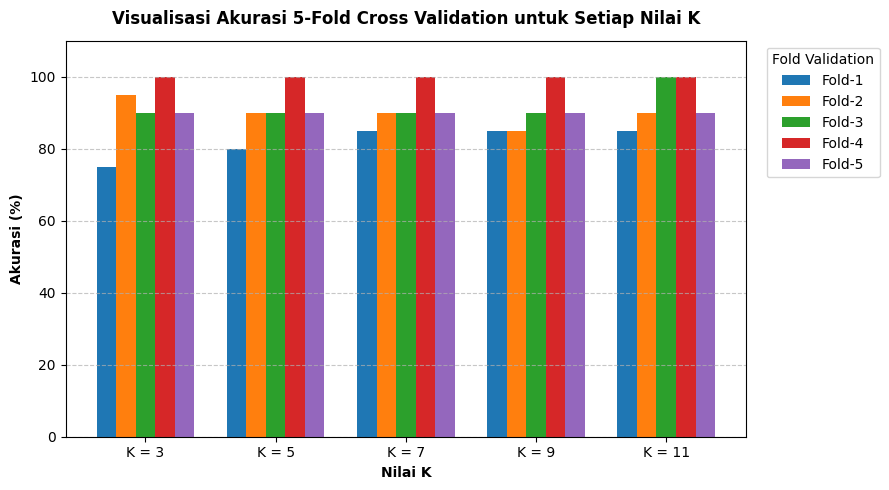

In [37]:

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# 1. Preprocessing & Scaling Seluruh Dataset (100 Data)
df_all_scaled = preprocess_and_scale(df)
X_all = df_all_scaled[kolom_fitur].values
y_all = df_all_scaled[kolom_target].values

list_k = [3, 5, 7, 9, 11]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary untuk menyimpan hasil akurasi tiap Fold
dict_fold_acc = {f"Fold-{i+1} (%)": [] for i in range(5)}
dict_fold_acc['Nilai K'] = [f"K = {k}" for k in list_k]

# 2. Iterasi Pengujian K-Fold untuk Setiap Nilai K
for k in list_k:
    fold_idx = 0
    for train_index, test_index in skf.split(X_all, y_all):
        X_tr_f, X_te_f = X_all[train_index], X_all[test_index]
        y_tr_f, y_te_f = y_all[train_index], y_all[test_index]

        y_pred_f = [prediksi_knn_tunggal(X_tr_f, y_tr_f, x_val, k=k)[0] for x_val in X_te_f]
        acc_f = accuracy_score(y_te_f, y_pred_f) * 100
        dict_fold_acc[f"Fold-{fold_idx+1} (%)"].append(round(acc_f, 2))
        fold_idx += 1

# 3. Pembentukan Tabel Rekapitulasi Cross Validation
df_cv_all = pd.DataFrame(dict_fold_acc)
fold_cols = [f"Fold-{i+1} (%)" for i in range(5)]
df_cv_all['Rata-rata Akurasi (%)'] = df_cv_all[fold_cols].mean(axis=1).round(2)

# Reorder kolom tabel
df_cv_tabel = df_cv_all[['Nilai K'] + fold_cols + ['Rata-rata Akurasi (%)']]

display(HTML("<b>=== SEL 7: HASIL 5-FOLD CROSS VALIDATION UNTUK SETIAP NILAI K ===</b>"))
display(HTML("<b>Tabel 7.1: Rekapitulasi Akurasi Cross Validation Tiap Fold (100 Data):</b>"))
display(df_cv_tabel.style.hide(axis='index'))

# 4. Visualisasi Grafik Batang (Bar Chart) Hasil Fold Masing-masing K
plt.figure(figsize=(9, 5))
x = np.arange(len(list_k))
width = 0.15

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i in range(5):
    plt.bar(x + (i - 2) * width, df_cv_all[f"Fold-{i+1} (%)"], width=width, label=f'Fold-{i+1}', color=colors[i])

plt.title('Visualisasi Akurasi 5-Fold Cross Validation untuk Setiap Nilai K', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Nilai K', fontsize=10, fontweight='bold')
plt.ylabel('Akurasi (%)', fontsize=10, fontweight='bold')
plt.xticks(x, [f'K = {k}' for k in list_k])
plt.ylim(0, 110)
plt.legend(title='Fold Validation', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

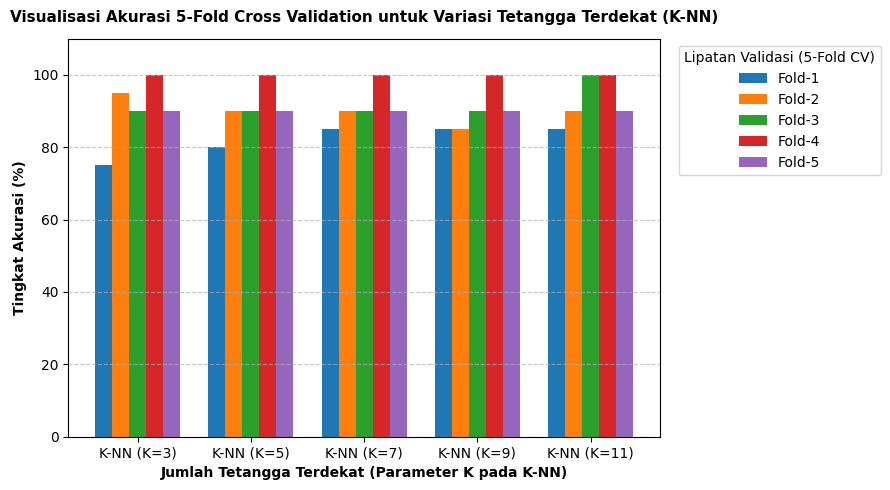

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Visualisasi Grafik Batang (Bar Chart) dengan Penjelasan Istilah yang Jelas
plt.figure(figsize=(9, 5))
x = np.arange(len(list_k))
width = 0.15
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i in range(5):
    plt.bar(x + (i - 2) * width, df_cv_all[f"Fold-{i+1} (%)"], width=width, label=f'Fold-{i+1}', color=colors[i])

# Judul dan Label Sumbu yang Diperjelas
plt.title('Visualisasi Akurasi 5-Fold Cross Validation untuk Variasi Tetangga Terdekat (K-NN)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Jumlah Tetangga Terdekat (Parameter K pada K-NN)', fontsize=10, fontweight='bold')
plt.ylabel('Tingkat Akurasi (%)', fontsize=10, fontweight='bold')
plt.xticks(x, [f'K-NN (K={k})' for k in list_k])
plt.ylim(0, 110)
plt.legend(title='Lipatan Validasi (5-Fold CV)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()